<a href="https://colab.research.google.com/github/AhmedAlwaqidi/car_plates_model_reader/blob/main/car_plates_model_reader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ultralytics easyocr huggingface_hub

In [ ]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import easyocr
import numpy as np



In [ ]:
model_path = hf_hub_download(
    repo_id="morsetechlab/yolov11-license-plate-detection",
    filename="license-plate-finetune-v1n.pt"
)

print("Model downloaded:", model_path)

model = YOLO(model_path)

Model downloaded: /root/.cache/huggingface/hub/models--morsetechlab--yolov11-license-plate-detection/snapshots/251a30d7daedca065f56e04b0af04052c907c68f/license-plate-finetune-v1n.pt



image 1/1 /content/car_plates/car_1.jpg: 384x640 1 License_Plate, 188.4ms
Speed: 6.4ms preprocess, 188.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


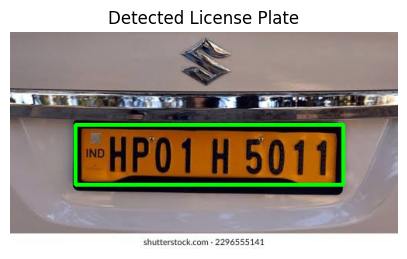


========== PLATE 1 ==========


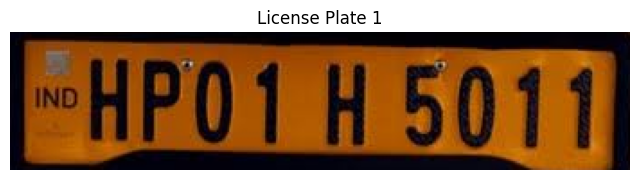

Detected Number: IND
Confidence: 99.25 %
Detected Number: HPO1H5011
Confidence: 38.96 %


In [124]:
# image_path = "/content/car_ye_plates/car_ye_1.jpg"
image_path = "/content/car_plates/car_1.jpg"


results = model.predict(
    source=image_path,
    conf=0.25,
    imgsz=640
)

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
reader = easyocr.Reader(["en"])

plates = []

for result in results:

    boxes = result.boxes.xyxy.cpu().numpy()

    for box in boxes:

        x1, y1, x2, y2 = map(int, box)

        # Draw rectangle around plate
        cv2.rectangle(
            image_rgb,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        # Crop the plate
        plate = image[y1:y2, x1:x2]

        plates.append(plate)


plt.figure(figsize=(15/3, 10/3))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Detected License Plate")
plt.show()

for i, plate in enumerate(plates):

    print(f"\n========== PLATE {i + 1} ==========")

    # Show cropped plate
    plate_rgb = cv2.cvtColor(plate, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 3))
    plt.imshow(plate_rgb)
    plt.axis("off")
    plt.title(f"License Plate {i + 1}")
    plt.show()

    # OCR
    ocr_results = reader.readtext(plate)

    if not ocr_results:
        print("Could not read the plate.")

    else:
        for bbox, text, confidence in ocr_results:

            # Remove spaces
            plate_number = text.replace(" ", "")

            print("Detected Number:", plate_number)
            print("Confidence:", round(confidence * 100, 2), "%")
